# Logistic Regression – Car Crash Severity Prediction
**Target Variable:** `Severity` (0 = Minor/No Injury, 1 = Severe/Fatal)  
**Dataset:** Car Crash – 112,660 records, 97 features (fully preprocessed)  
**Goal:** Predict whether a crash will result in a severe outcome using Logistic Regression.

---
## Step 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Step 2 – Load the Preprocessed Data

In [2]:
df = pd.read_csv("Car_Crash_Fully_Preprocessed.csv")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Missing : {df.isnull().sum().sum()}")
df.head()

Rows    : 112,660
Columns : 98
Missing : 0


,Severity,ClearWeather,Highway,Daylight,CrashType_A,CrashType_B,CrashType_C,CrashType_D,CrashType_E,CrashType_F,...,Month_11,Month_12,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9
0,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## Step 3 – Separate Features (X) and Target (y)
- **X** = all columns except `Severity` (the predictors)
- **y** = `Severity` (what we are predicting)

In [3]:
X = df.drop(columns=["Severity"])
y = df["Severity"]

print(f"Feature matrix X : {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Target vector  y : {y.shape[0]:,} values")
print(f"\nFeature names:\n{list(X.columns)}")

Feature matrix X : 112,660 rows x 97 columns
Target vector  y : 112,660 values

Feature names:
['ClearWeather', 'Highway', 'Daylight', 'CrashType_A', 'CrashType_B', 'CrashType_C', 'CrashType_D', 'CrashType_E', 'CrashType_F', 'CrashType_G', 'ViolCat_1', 'ViolCat_10', 'ViolCat_11', 'ViolCat_12', 'ViolCat_24', 'ViolCat_3', 'ViolCat_4', 'ViolCat_6', 'ViolCat_7', 'ViolCat_8', 'ViolCat_9', 'County_0', 'County_1', 'County_10', 'County_11', 'County_12', 'County_13', 'County_14', 'County_15', 'County_16', 'County_17', 'County_18', 'County_19', 'County_2', 'County_20', 'County_21', 'County_22', 'County_23', 'County_24', 'County_25', 'County_26', 'County_27', 'County_28', 'County_29', 'County_3', 'County_30', 'County_31', 'County_32', 'County_33', 'County_34', 'County_35', 'County_36', 'County_37', 'County_38', 'County_39', 'County_4', 'County_40', 'County_41', 'County_42', 'County_43', 'County_44', 'County_45', 'County_46', 'County_47', 'County_48', 'County_49', 'County_5', 'County_50', 'County_

---
## Step 4 – Check Class Imbalance
Class imbalance occurs when one outcome is far more common than the other.  
If ignored, the model may just always predict the majority class and appear accurate while being useless.

Class Distribution:
  Severity = 0 (Minor)  : 104,742  (93.0%)
  Severity = 1 (Severe) :   7,918  (7.0%)

>> Imbalance detected (93% / 7%).
   Solution: use class_weight='balanced' in the model so severe crashes
   are weighted ~13x more heavily during training.


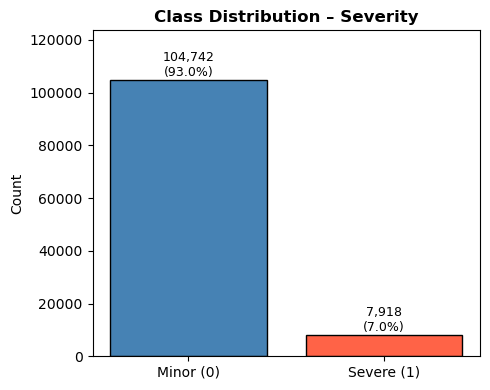

In [4]:
counts = y.value_counts()

print("Class Distribution:")
print(f"  Severity = 0 (Minor)  : {counts[0]:>7,}  ({counts[0]/len(y)*100:.1f}%)")
print(f"  Severity = 1 (Severe) : {counts[1]:>7,}  ({counts[1]/len(y)*100:.1f}%)")
print()
print(">> Imbalance detected (93% / 7%).")
print("   Solution: use class_weight='balanced' in the model so severe crashes")
print("   are weighted ~13x more heavily during training.")

# Quick bar chart
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Minor (0)", "Severe (1)"], counts.values, color=["steelblue", "tomato"], edgecolor="black")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{val:,}\n({val/len(y)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Class Distribution – Severity", fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts[0] * 1.18)
plt.tight_layout()
plt.show()

---
## Step 5 – Train / Test Split
- **75% training** – the model learns from this data
- **25% testing** – held out and never seen during training; used to evaluate real-world performance
- `stratify=y` ensures the 93/7 class ratio is preserved in both splits

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print()
print("Training class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Training set : 84,495 rows
Test set     : 28,165 rows

Training class distribution:
Severity
0    78556
1     5939
Name: count, dtype: int64

Test class distribution:
Severity
0    26186
1     1979
Name: count, dtype: int64


---
## Step 6 – Feature Scaling (StandardScaler)
Logistic Regression uses gradient-based optimization. When features are on very different scales,  
the optimizer struggles. StandardScaler transforms every feature to **mean = 0, std = 1**.

> **Important:** Fit the scaler **only on training data**, then apply it to test data.  
> Fitting on test data would cause data leakage.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn scale from train, apply to train
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test (no re-fitting)

print("Scaling complete.")
print(f"  Training mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"  Training std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}")

Scaling complete.
  Training mean (first 5 features): [-0.  0.  0. -0. -0.]
  Training std  (first 5 features): [1. 1. 1. 1. 1.]


---
## Step 7 – Build and Train the Logistic Regression Model
Key parameters:
- `class_weight='balanced'` – penalizes misclassifying the rare severe class more heavily
- `solver='lbfgs'` – efficient optimizer for binary classification
- `max_iter=1000` – maximum iterations allowed for convergence

In [7]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
)

model.fit(X_train_scaled, y_train)

print("Model training complete.")
print(f"  Solver          : {model.solver}")
print(f"  Iterations used : {model.n_iter_[0]}")
print(f"  Class weight    : balanced")
print(f"  Number of features: {model.n_features_in_}")

Model training complete.
  Solver          : lbfgs
  Iterations used : 13
  Class weight    : balanced
  Number of features: 97


---
## Step 8 – Generate Predictions
- `y_pred` – hard class labels (0 or 1)
- `y_pred_prob` – probability that each crash is Severe (used for AUC-ROC)

In [8]:
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # P(Severity = 1)

print(f"Predictions generated for {len(y_pred):,} test records.")
print(f"\nSample predicted labels      : {y_pred[:10]}")
print(f"Sample predicted probabilities: {y_pred_prob[:10].round(3)}")

Predictions generated for 28,165 test records.

Sample predicted labels      : [0 0 0 1 1 0 0 0 0 0]
Sample predicted probabilities: [0.212 0.324 0.417 0.805 0.773 0.367 0.296 0.264 0.109 0.321]


---
## Step 9 – Evaluate Model Performance
### Metrics explained:
| Metric | What it means |
|---|---|
| **Precision** | Of crashes predicted Severe, how many actually were? |
| **Recall** | Of crashes that were actually Severe, how many did we catch? |
| **F1-Score** | Harmonic mean of precision and recall |
| **AUC-ROC** | Overall ranking quality — 0.5 = random, 1.0 = perfect |

In [9]:
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"AUC-ROC Score : {auc_score:.4f}")
print()

if auc_score >= 0.90:
    rating = "Excellent"
elif auc_score >= 0.80:
    rating = "Good"
elif auc_score >= 0.70:
    rating = "Acceptable"
else:
    rating = "Poor"
print(f"Rating: {rating}  (>0.70 = Acceptable | >0.80 = Good | >0.90 = Excellent)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Minor (0)", "Severe (1)"]))

AUC-ROC Score : 0.7529

Rating: Acceptable  (>0.70 = Acceptable | >0.80 = Good | >0.90 = Excellent)

Classification Report:
              precision    recall  f1-score   support

   Minor (0)       0.97      0.72      0.82     26186
  Severe (1)       0.15      0.66      0.24      1979

    accuracy                           0.71     28165
   macro avg       0.56      0.69      0.53     28165
weighted avg       0.91      0.71      0.78     28165



---
## Step 10 – Confusion Matrix
Shows exactly how many predictions were correct and incorrect for each class.

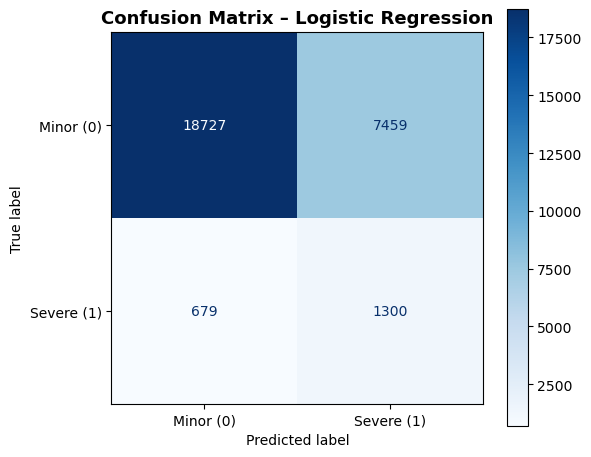

True Negatives  (correctly predicted Minor)  : 18,727
False Positives (predicted Severe, was Minor): 7,459
False Negatives (predicted Minor, was Severe): 679
True Positives  (correctly predicted Severe) : 1,300


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Minor (0)", "Severe (1)"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix – Logistic Regression", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Minor)  : {tn:,}")
print(f"False Positives (predicted Severe, was Minor): {fp:,}")
print(f"False Negatives (predicted Minor, was Severe): {fn:,}")
print(f"True Positives  (correctly predicted Severe) : {tp:,}")

---
## Step 11 – AUC-ROC Curve
The ROC curve plots the **True Positive Rate** vs **False Positive Rate** at every possible threshold.  
The **Area Under the Curve (AUC)** summarizes the model's ability to distinguish between the two classes.  
A diagonal line (AUC = 0.50) represents a random classifier.

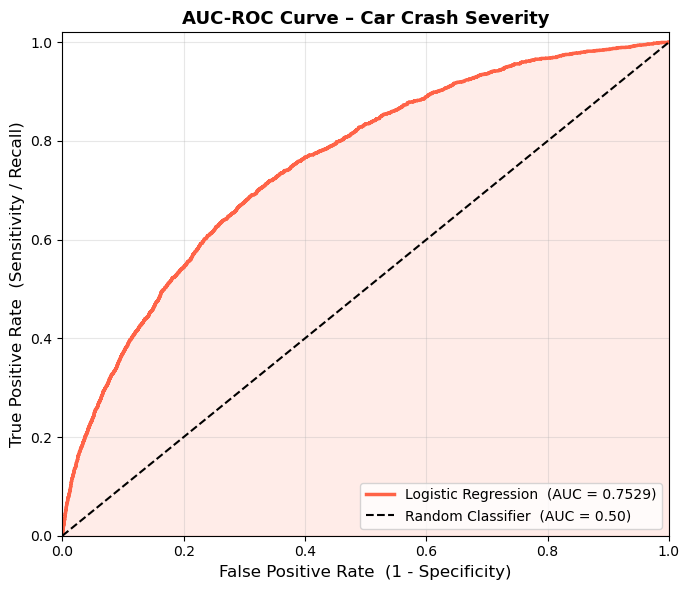

AUC-ROC Score: 0.7529
Chart saved to: AUC_ROC_Curve.png


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="tomato", lw=2.5, label=f"Logistic Regression  (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier  (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.12, color="tomato")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate  (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate  (Sensitivity / Recall)", fontsize=12)
ax.set_title("AUC-ROC Curve – Car Crash Severity", fontweight="bold", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("AUC_ROC_Curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC-ROC Score: {auc_score:.4f}")
print("Chart saved to: AUC_ROC_Curve.png")

---
## Step 12 – Top 10 Most Influential Features
Logistic Regression coefficients tell us how much each feature pushes the prediction toward Severe (positive) or Minor (negative).  
Larger absolute value = stronger influence on the prediction.

Top 10 Most Influential Features:


,Feature,Coefficient
0,CrashType_C,-0.488601
1,CrashType_G,0.350741
2,Daylight,-0.232757
3,ViolCat_1,0.221752
4,CrashType_E,0.168991
5,Highway,0.153802
6,CrashType_F,0.151151
7,ViolCat_4,-0.137641
8,CrashType_A,0.131240
9,ViolCat_9,-0.120919


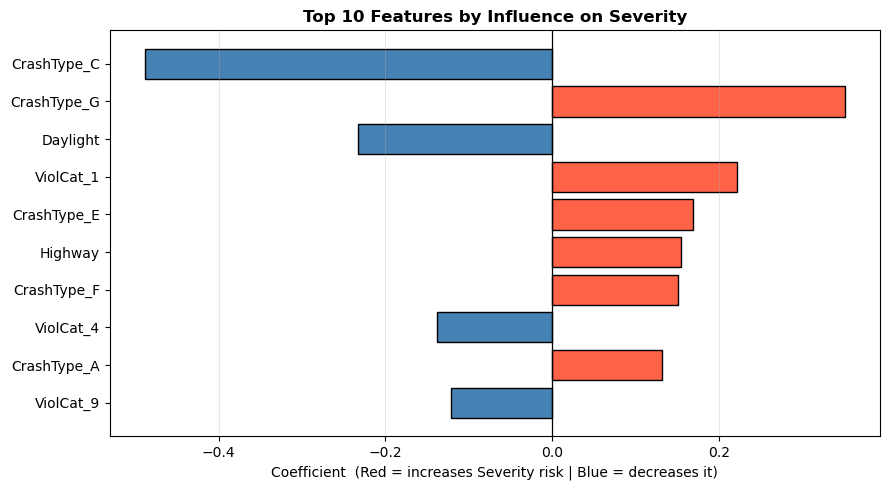

Chart saved to: Feature_Importance.png


In [12]:
coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": model.coef_[0]
})
coef_df["Abs_Coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coef", ascending=False).head(10).reset_index(drop=True)

print("Top 10 Most Influential Features:")
display(coef_df[["Feature", "Coefficient"]])

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1], color=colors[::-1], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Top 10 Features by Influence on Severity", fontweight="bold", fontsize=12)
ax.set_xlabel("Coefficient  (Red = increases Severity risk | Blue = decreases it)", fontsize=10)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("Feature_Importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to: Feature_Importance.png")

---
## Step 13 – Predicted Probability Distribution
Shows how well the model separates the two classes.  
Ideally, blue (Minor) peaks near 0 and red (Severe) peaks near 1.

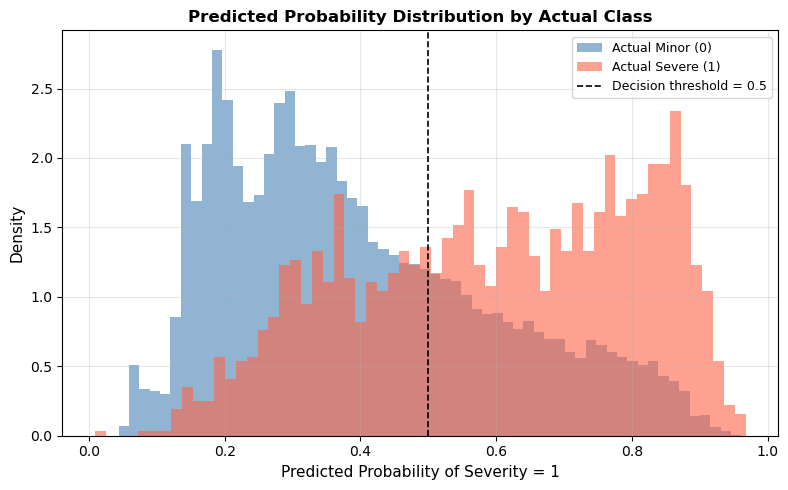

Chart saved to: Probability_Distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_pred_prob[y_test == 0], bins=60, alpha=0.6, color="steelblue",
        label="Actual Minor (0)", density=True)
ax.hist(y_pred_prob[y_test == 1], bins=60, alpha=0.6, color="tomato",
        label="Actual Severe (1)", density=True)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision threshold = 0.5")
ax.set_xlabel("Predicted Probability of Severity = 1", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Predicted Probability Distribution by Actual Class", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Probability_Distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to: Probability_Distribution.png")

---
## Step 14 – Full Results Summary

In [14]:
print("=" * 55)
print("       LOGISTIC REGRESSION – FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Dataset           : Car Crash ({len(df):,} records)")
print(f"  Target            : Severity (0=Minor, 1=Severe)")
print(f"  Train / Test split: 75% / 25% (stratified)")
print(f"  Features used     : {X.shape[1]}")
print(f"  Class weighting   : Balanced")
print()
print(f"  AUC-ROC Score     : {auc_score:.4f}  [{rating}]")
print()
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"  True  Positives   : {tp:,}   (Severe crashes correctly identified)")
print(f"  False Negatives   : {fn:,}   (Severe crashes missed)")
print(f"  True  Negatives   : {tn:,}  (Minor crashes correctly identified)")
print(f"  False Positives   : {fp:,}   (Minor crashes incorrectly flagged as Severe)")
print()
print("  Saved files:")
print("    AUC_ROC_Curve.png")
print("    Feature_Importance.png")
print("    Probability_Distribution.png")
print("=" * 55)

       LOGISTIC REGRESSION – FINAL RESULTS SUMMARY
  Dataset           : Car Crash (112,660 records)
  Target            : Severity (0=Minor, 1=Severe)
  Train / Test split: 75% / 25% (stratified)
  Features used     : 97
  Class weighting   : Balanced

  AUC-ROC Score     : 0.7529  [Acceptable]

  True  Positives   : 1,300   (Severe crashes correctly identified)
  False Negatives   : 679   (Severe crashes missed)
  True  Negatives   : 18,727  (Minor crashes correctly identified)
  False Positives   : 7,459   (Minor crashes incorrectly flagged as Severe)

  Saved files:
    AUC_ROC_Curve.png
    Feature_Importance.png
    Probability_Distribution.png
